# Phase 1: UPC Campus WiFi Dataset Exploration
This notebook performs a comprehensive exploratory data analysis (EDA) of the UPC Campus WiFi dataset. The dataset contains daily logs of WiFi Access Point (AP) user counts and spatial region maps for multiple floors of the campus.

### Objectives:
- Investigate and profile the structure, size, and health of the dataset.
- Calculate essential descriptive statistics of user counts and network activities.
- Analyze temporal patterns of user connections (daily, hourly, weekly).
- Understand spatial and AP-level activity distributions.
- Detect any data quality issues, sampling anomalies, or missing information.

We use a modular analysis approach, importing helper functions from `prediction/src/dataset_inspection.py` while performing visualizations and detailed breakdowns directly in this notebook.


## 1. Setup & Environment
First, we load the required visualization libraries, set styling preferences, and import the custom inspection script `dataset_inspection.py` to read our raw data.


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Add project root to path to allow importing src module
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from prediction.src import dataset_inspection as di

# Output directory for saved plots
analysis_out_dir = os.path.join(project_root, 'data', 'processed', 'analysis')
os.makedirs(analysis_out_dir, exist_ok=True)
print(f"Project Root: {project_root}")
print(f"Analysis Output Dir: {analysis_out_dir}")


Project Root: C:\Users\samar\OneDrive\Desktop\wifi congestion mangement project\predictive-bandwidth-congestion-manager
Analysis Output Dir: C:\Users\samar\OneDrive\Desktop\wifi congestion mangement project\predictive-bandwidth-congestion-manager\data\processed\analysis


## 2. Dataset Loading
We load all `campus_users_*.csv` files located in the `data/raw` directory and combine them into a single, memory-efficient DataFrame. Timestamps are parsed as local CEST datetimes.


In [2]:
data_dir = os.path.join(project_root, 'data', 'raw')
print(f"Loading files from: {data_dir} ...")

df, num_files, invalid_timestamp_count = di.load_dataset(data_dir)
print(f"Loaded {num_files} files.")
print(f"Total rows: {len(df):,}")


Loading files from: C:\Users\samar\OneDrive\Desktop\wifi congestion mangement project\predictive-bandwidth-congestion-manager\data\raw ...


Loaded 62 files.
Total rows: 1,267,357


## 3. Dataset Profiling & Basic Quality Metrics
We calculate the basic properties and data quality parameters required for profiling:
- Number of files
- Total records
- Unique APs
- Date/time range
- Records per AP
- Missing values count
- Duplicate rows
- Invalid timestamps


In [3]:
# 1. Number of files
print(f"1. Number of files: {num_files}")

# 2. Total number of records
print(f"2. Total number of records: {len(df):,}")

# 3. Number of unique APs
unique_aps = df['AP_id'].unique()
print(f"3. Number of unique APs: {len(unique_aps)}")

# 4. Date/time range
min_time = df['ParsedTime'].min()
max_time = df['ParsedTime'].max()
print(f"4. Date/time range: {min_time} to {max_time}")

# 5. Number of records per AP statistics
records_per_ap = df['AP_id'].value_counts()
print("5. Records per AP statistics:")
print(f"   - Minimum: {records_per_ap.min()}")
print(f"   - Maximum: {records_per_ap.max()}")
print(f"   - Mean: {records_per_ap.mean():.2f}")
print(f"   - Median: {records_per_ap.median():.2f}")
print(f"   - Std Dev: {records_per_ap.std():.2f}")

# 7. Missing values
missing_counts = df.isna().sum()
print("\n7. Missing values per column:")
print(missing_counts)

# 8. Duplicate rows
duplicates_count = df.duplicated(subset=['AP_id', 'Time', 'Users']).sum()
print(f"\n8. Duplicate rows (based on AP_id, Time, Users): {duplicates_count}")

# 9. Invalid timestamps
print(f"9. Invalid timestamps: {invalid_timestamp_count}")


1. Number of files: 62
2. Total number of records: 1,267,357
3. Number of unique APs: 247
4. Date/time range: 2023-04-18 00:07:30 to 2023-06-18 23:47:22
5. Records per AP statistics:
   - Minimum: 5131
   - Maximum: 5131
   - Mean: 5131.00
   - Median: 5131.00
   - Std Dev: 0.00

7. Missing values per column:
AP_id         0
Time          0
Users         0
ParsedTime    0
dtype: int64



8. Duplicate rows (based on AP_id, Time, Users): 0
9. Invalid timestamps: 0


## 4. Sampling Interval Analysis
The data collection is designed to capture user counts periodically. Here we calculate the actual time differences between consecutive observations for each AP. We do not assume a fixed 15-minute interval, but instead analyze the empirical distribution.


In [4]:
print("Calculating sampling intervals per AP...")
intervals = di.get_sampling_intervals(df)

# 6. Sampling interval statistics (in minutes)
print("6. Sampling interval statistics (minutes):")
print(f"   - Minimum interval: {intervals.min():.2f} min")
print(f"   - Maximum interval: {intervals.max():.2f} min")
print(f"   - Median interval: {intervals.median():.2f} min")
print(f"   - Mean interval: {intervals.mean():.2f} min")
print(f"   - Std Dev: {intervals.std():.2f} min")


Calculating sampling intervals per AP...


6. Sampling interval statistics (minutes):
   - Minimum interval: 15.83 min
   - Maximum interval: 35.83 min
   - Median interval: 16.62 min
   - Mean interval: 17.40 min
   - Std Dev: 2.48 min


### Visualization: Sampling Interval Distribution
We plot the distribution of sampling intervals to identify the typical reporting cycle and any deviations or anomalies.


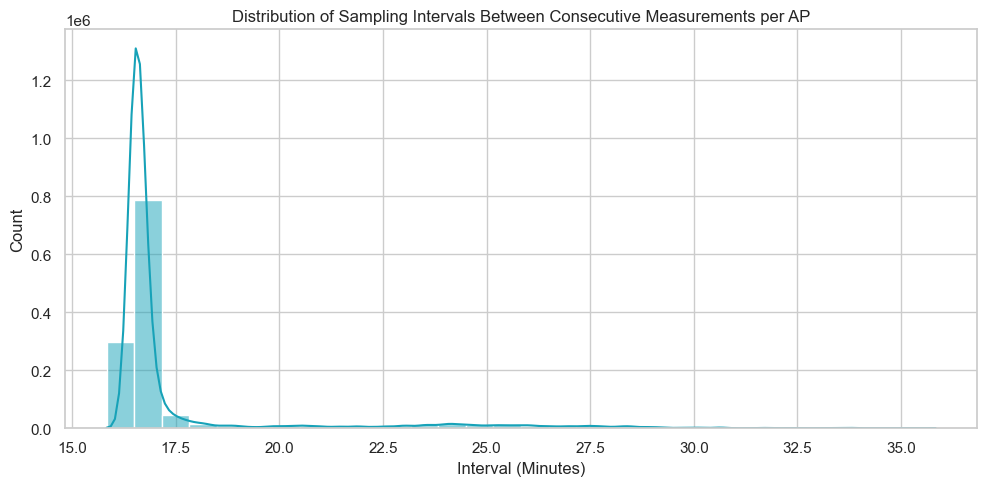

Saved: C:\Users\samar\OneDrive\Desktop\wifi congestion mangement project\predictive-bandwidth-congestion-manager\data\processed\analysis\sampling_interval_dist.png


In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(intervals, kde=True, bins=30, color='#17a2b8')
plt.title('Distribution of Sampling Intervals Between Consecutive Measurements per AP')
plt.xlabel('Interval (Minutes)')
plt.ylabel('Count')
plt.tight_layout()
plot_path = os.path.join(analysis_out_dir, 'sampling_interval_dist.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved: {plot_path}")


## 5. User Count Statistics
Let's look at the basic statistics of user counts across all observations and determine the prevalence of inactive (zero-user) states.
- Minimum, maximum, mean, median, standard deviation of user counts
- Percentage of records where Users = 0


In [6]:
user_col = df['Users']

# 10. User count statistics
print("10. User count statistics:")
print(f"    - Minimum users: {user_col.min()}")
print(f"    - Maximum users: {user_col.max()}")
print(f"    - Mean users: {user_col.mean():.4f}")
print(f"    - Median users: {user_col.median()}")
print(f"    - Standard Deviation: {user_col.std():.4f}")

# 11. Percentage of records where Users = 0
zero_user_count = (user_col == 0).sum()
percent_zero_users = (zero_user_count / len(df)) * 100
print(f"\n11. Percentage of records with 0 users: {percent_zero_users:.2f}%")


10. User count statistics:
    - Minimum users: 0
    - Maximum users: 114
    - Mean users: 1.3474
    - Median users: 0.0
    - Standard Deviation: 3.1351

11. Percentage of records with 0 users: 52.98%


## 6. Access Point Activity & User Distribution
In this section, we analyze the spatial utilization of the network by calculating user distribution metrics and identifying the busiest and least-used APs.
- 12. User distribution across APs
- 15. AP activity distribution (percentage of time AP has active users)


In [7]:
ap_stats = df.groupby('AP_id').agg(
    mean_users=('Users', 'mean'),
    max_users=('Users', 'max'),
    active_pct=('Users', lambda x: (x > 0).mean() * 100)
).reset_index()

print("AP user metrics summary:")
print(ap_stats[['mean_users', 'max_users', 'active_pct']].describe())


AP user metrics summary:


       mean_users   max_users  active_pct
count  247.000000  247.000000  247.000000
mean     1.347425   21.441296   47.022741
std      0.889451   16.292162   35.395086
min      0.000000    0.000000    0.000000
25%      0.589943    9.000000   16.682908
50%      1.302475   17.000000   26.310661
75%      1.777919   31.000000   87.078542
max      4.516274  114.000000   99.961021


### Visualizations: User Distribution and Busiest / Least-Used APs
We render:
1. User distribution across APs (density of average user count).
2. Top 20 busiest APs.
3. Bottom 20 least-used APs.


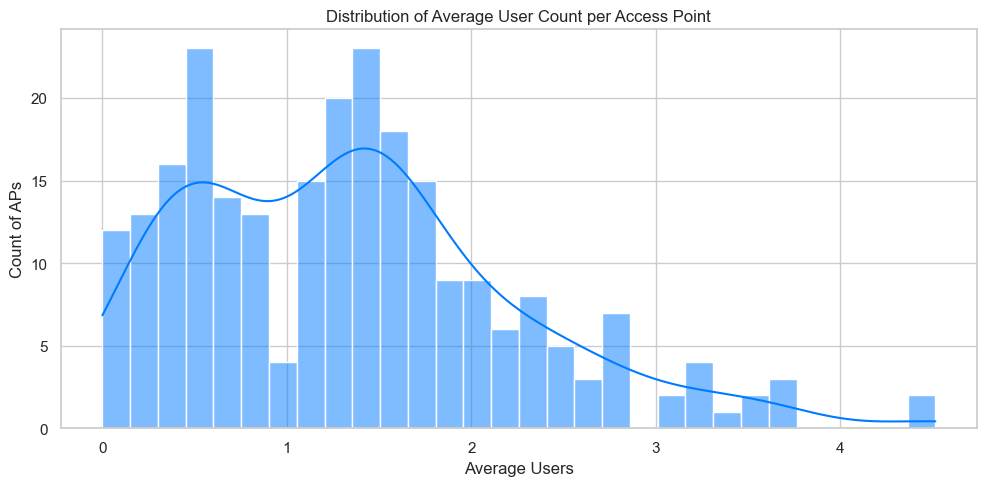

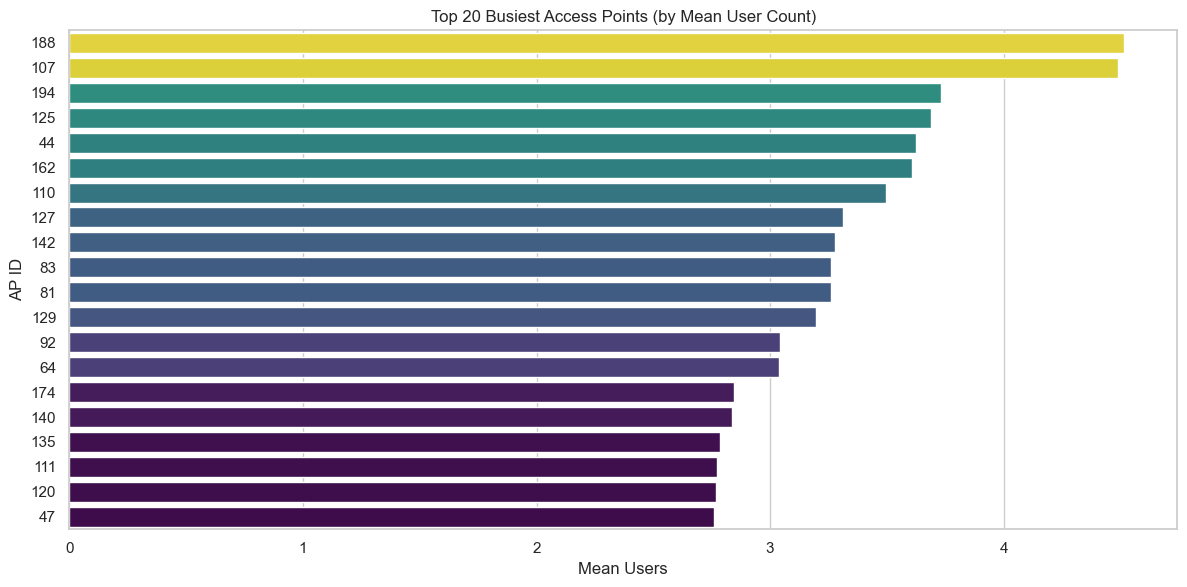

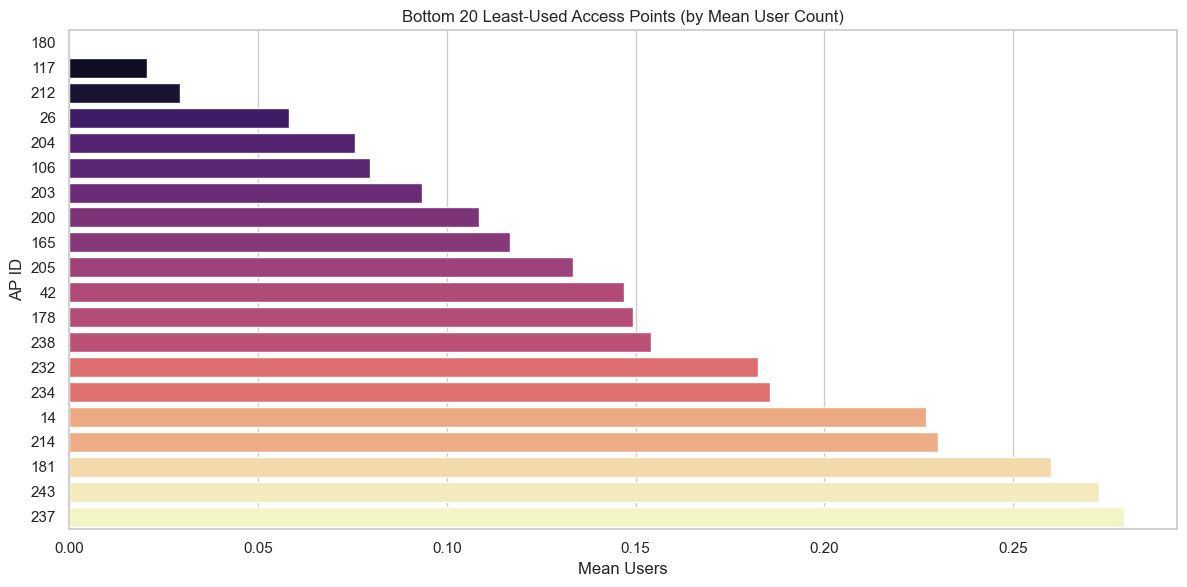

In [8]:
# Plot 1: User distribution across APs
plt.figure(figsize=(10, 5))
sns.histplot(ap_stats['mean_users'], kde=True, bins=30, color='#007bff')
plt.title('Distribution of Average User Count per Access Point')
plt.xlabel('Average Users')
plt.ylabel('Count of APs')
plt.tight_layout()
plot_path = os.path.join(analysis_out_dir, 'ap_user_distribution.png')
plt.savefig(plot_path, dpi=150)
plt.show()

# Plot 2: Top 20 busiest APs
top_20 = ap_stats.sort_values(by='mean_users', ascending=False).head(20)
plt.figure(figsize=(12, 6))
sns.barplot(x='mean_users', y=top_20['AP_id'].astype(str), data=top_20, palette='viridis', hue='mean_users', legend=False)
plt.title('Top 20 Busiest Access Points (by Mean User Count)')
plt.xlabel('Mean Users')
plt.ylabel('AP ID')
plt.tight_layout()
plot_path = os.path.join(analysis_out_dir, 'top_20_busiest_aps.png')
plt.savefig(plot_path, dpi=150)
plt.show()

# Plot 3: Bottom 20 least-used APs
bottom_20 = ap_stats.sort_values(by='mean_users', ascending=True).head(20)
plt.figure(figsize=(12, 6))
sns.barplot(x='mean_users', y=bottom_20['AP_id'].astype(str), data=bottom_20, palette='magma', hue='mean_users', legend=False)
plt.title('Bottom 20 Least-Used Access Points (by Mean User Count)')
plt.xlabel('Mean Users')
plt.ylabel('AP ID')
plt.tight_layout()
plot_path = os.path.join(analysis_out_dir, 'bottom_20_least_used_aps.png')
plt.savefig(plot_path, dpi=150)
plt.show()


### Visualization: AP × Hour Heatmap
To visualize network usage patterns across both space and time, we generate a heatmap of APs vs. Hour of Day. APs are sorted along the y-axis by their overall busiest level.


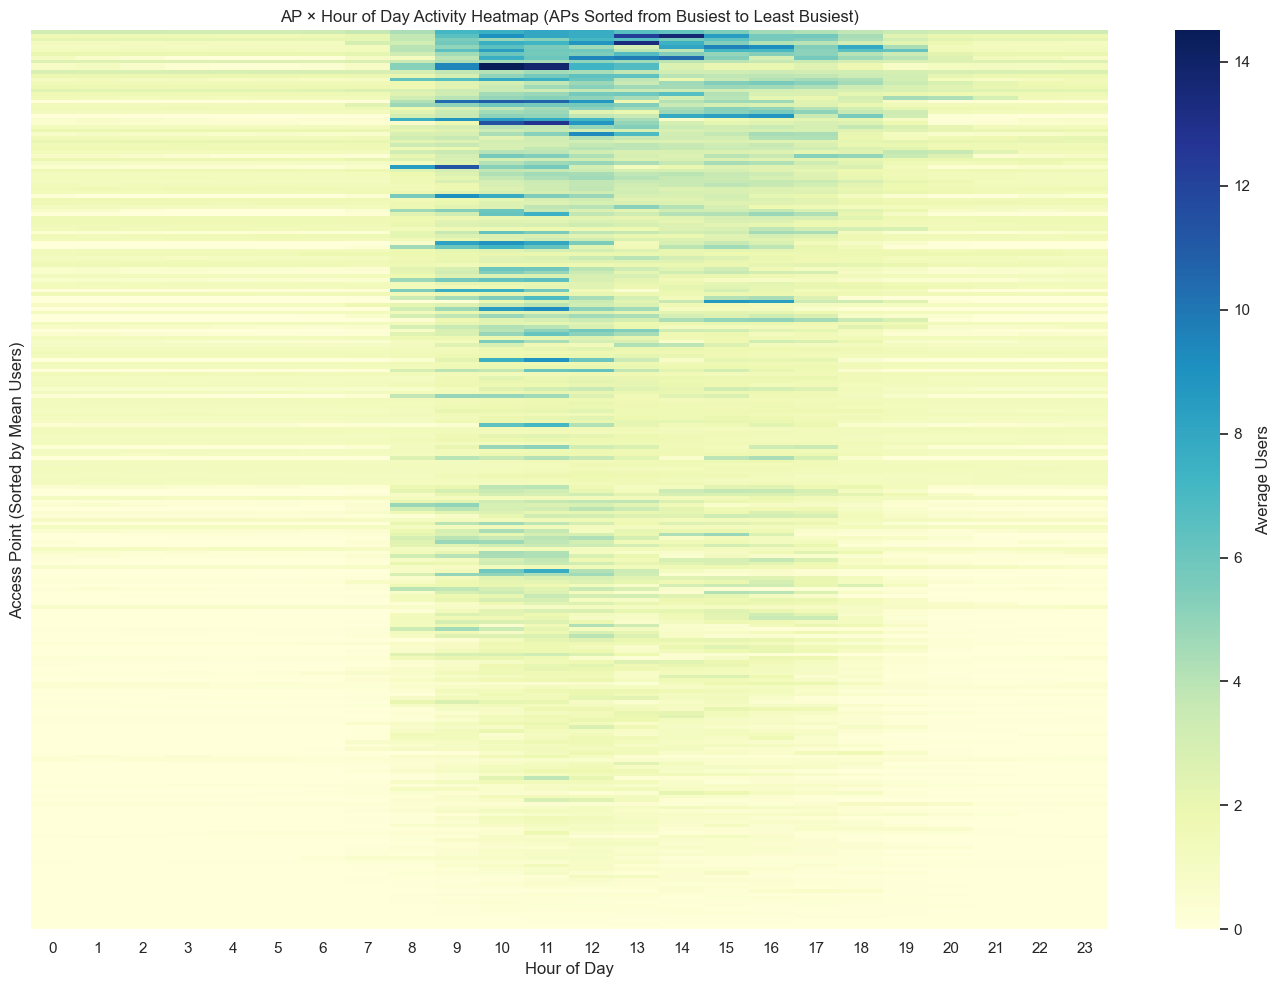

Saved: C:\Users\samar\OneDrive\Desktop\wifi congestion mangement project\predictive-bandwidth-congestion-manager\data\processed\analysis\ap_hour_heatmap.png


In [9]:
# Pivot data to get Hour of Day (columns) vs AP (rows)
pivot_df = df.groupby(['AP_id', df['ParsedTime'].dt.hour])['Users'].mean().unstack(fill_value=0)
# Sort by overall busiest APs
sorted_ap_ids = ap_stats.sort_values(by='mean_users', ascending=False)['AP_id']
pivot_df_sorted = pivot_df.reindex(sorted_ap_ids)

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_df_sorted, cmap='YlGnBu', cbar_kws={'label': 'Average Users'})
plt.title('AP × Hour of Day Activity Heatmap (APs Sorted from Busiest to Least Busiest)')
plt.xlabel('Hour of Day')
plt.ylabel('Access Point (Sorted by Mean Users)')
# Reduce y-ticks for cleaner display
plt.yticks([])
plt.tight_layout()
plot_path = os.path.join(analysis_out_dir, 'ap_hour_heatmap.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved: {plot_path}")


## 7. Temporal Patterns
We analyze how user patterns change over time:
- 13. Daily user patterns
- 14. Hourly user patterns
- Total users over time (line plot)
- Average users by hour of day (line plot)
- Average users by day of the week


C:\Users\samar\AppData\Local\Temp\ipykernel_24480\1973387087.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  timeline_df = df.set_index('ParsedTime').resample('1H')['Users'].sum()


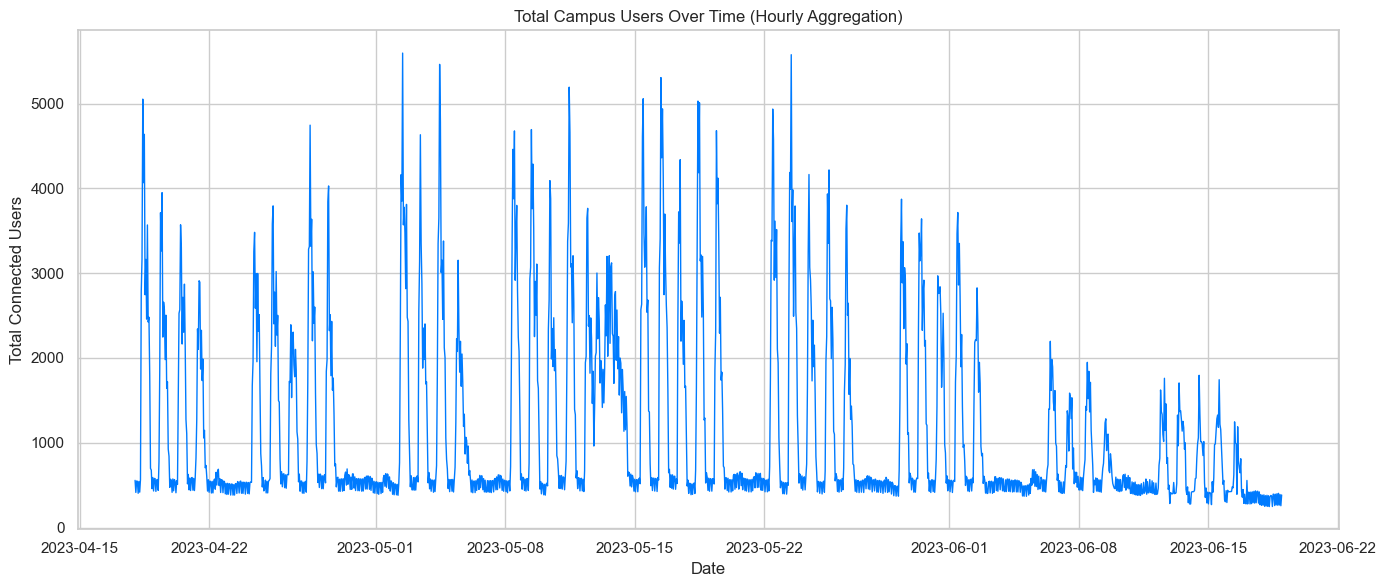

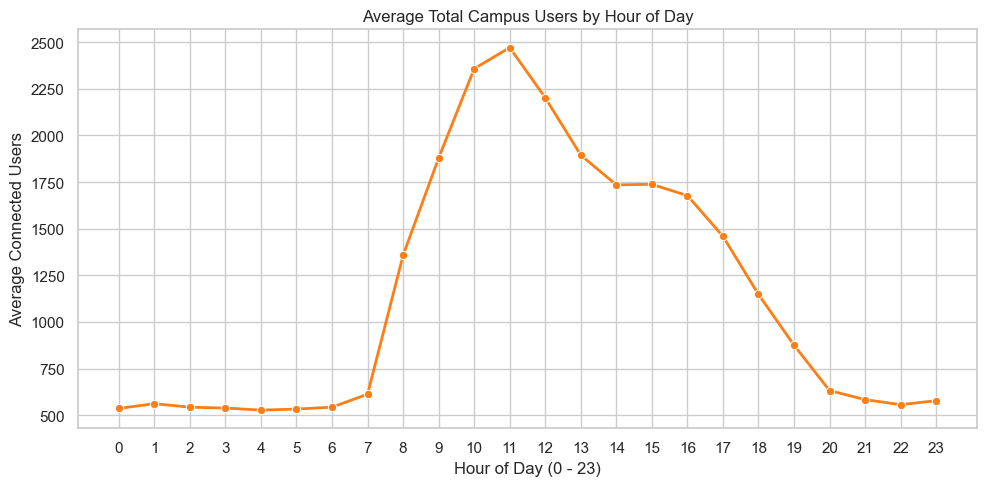

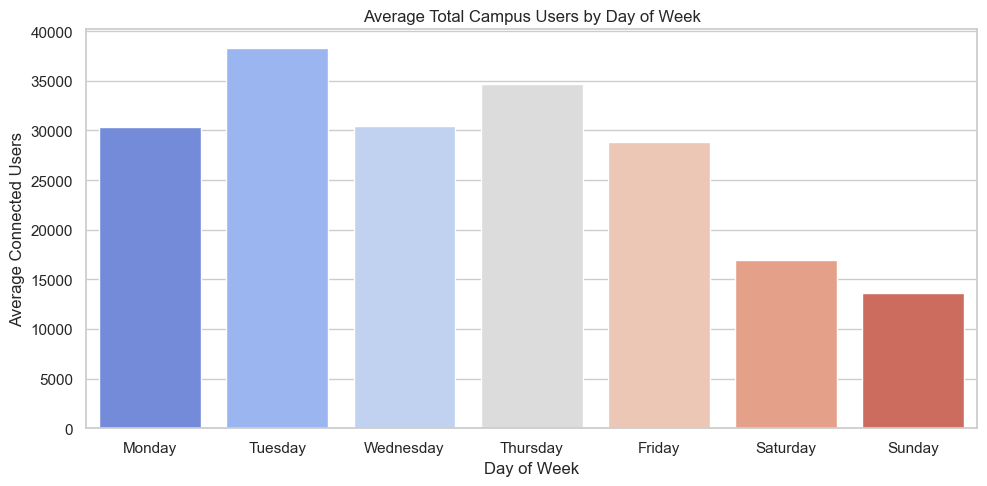

In [10]:
df['Date'] = df['ParsedTime'].dt.date
df['Hour'] = df['ParsedTime'].dt.hour
df['DayOfWeek'] = df['ParsedTime'].dt.day_name()

# 1. Total users over time (1-hour resampled)
timeline_df = df.set_index('ParsedTime').resample('1H')['Users'].sum()

plt.figure(figsize=(14, 6))
plt.plot(timeline_df.index, timeline_df.values, color='#007bff', linewidth=1)
plt.title('Total Campus Users Over Time (Hourly Aggregation)')
plt.xlabel('Date')
plt.ylabel('Total Connected Users')
plt.tight_layout()
plot_path = os.path.join(analysis_out_dir, 'total_users_over_time.png')
plt.savefig(plot_path, dpi=150)
plt.show()

# 2. Average users by hour of day (daily average of total campus users)
hourly_sum_df = df.groupby(['Date', 'Hour'])['Users'].sum().groupby('Hour').mean()

plt.figure(figsize=(10, 5))
sns.lineplot(x=hourly_sum_df.index, y=hourly_sum_df.values, marker='o', color='#fd7e14', linewidth=2)
plt.title('Average Total Campus Users by Hour of Day')
plt.xlabel('Hour of Day (0 - 23)')
plt.ylabel('Average Connected Users')
plt.xticks(range(0, 24))
plt.tight_layout()
plot_path = os.path.join(analysis_out_dir, 'avg_users_by_hour.png')
plt.savefig(plot_path, dpi=150)
plt.show()

# 3. Average users by day of week (daily average of total campus users)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_sum_df = df.groupby(['Date', 'DayOfWeek'])['Users'].sum().groupby('DayOfWeek').mean().reindex(day_order)

plt.figure(figsize=(10, 5))
sns.barplot(x=daily_sum_df.index, y=daily_sum_df.values, palette='coolwarm', hue=daily_sum_df.index, legend=False)
plt.title('Average Total Campus Users by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Connected Users')
plt.tight_layout()
plot_path = os.path.join(analysis_out_dir, 'avg_users_by_day_of_week.png')
plt.savefig(plot_path, dpi=150)
plt.show()


## 8. Spatial Region Maps Analysis
We inspect the region maps (`regions_map_floor_0.csv`, `regions_map_floor_1.csv`, `regions_map_floor_2.csv`) to understand how Access Points cover the grid locations.


In [11]:
maps = di.load_region_maps(data_dir)
print("Region Floor Map Shapes and Unique Values:")

map_ap_ids = set()
for floor, map_df in maps.items():
    # Convert dataframe values to a flat numpy array
    flat_vals = map_df.values.flatten()
    # Filter out empty/background values (value = 0)
    non_zero_vals = flat_vals[flat_vals != 0]
    unique_vals = np.unique(non_zero_vals)
    print(f"Floor {floor} map shape: {map_df.shape} | Unique non-zero values (AP IDs): {len(unique_vals)}")
    map_ap_ids.update(unique_vals)

print(f"Total unique AP IDs mapped in floor files: {len(map_ap_ids)}")

# Validate matching with campus users dataset
print(f"APs in data but NOT in maps: {len(set(unique_aps) - map_ap_ids)}")
print(f"APs in maps but NOT in data: {len(map_ap_ids - set(unique_aps))}")


Region Floor Map Shapes and Unique Values:
Floor 0 map shape: (335, 125) | Unique non-zero values (AP IDs): 73
Floor 1 map shape: (335, 125) | Unique non-zero values (AP IDs): 85
Floor 2 map shape: (335, 125) | Unique non-zero values (AP IDs): 89
Total unique AP IDs mapped in floor files: 247
APs in data but NOT in maps: 0
APs in maps but NOT in data: 0


### Visualization: Spatial Floor Layout Heatmaps
Let's render a quick visual representation of the floor grids to see the spatial partitioning. The non-zero values show where the APs are located / cover.


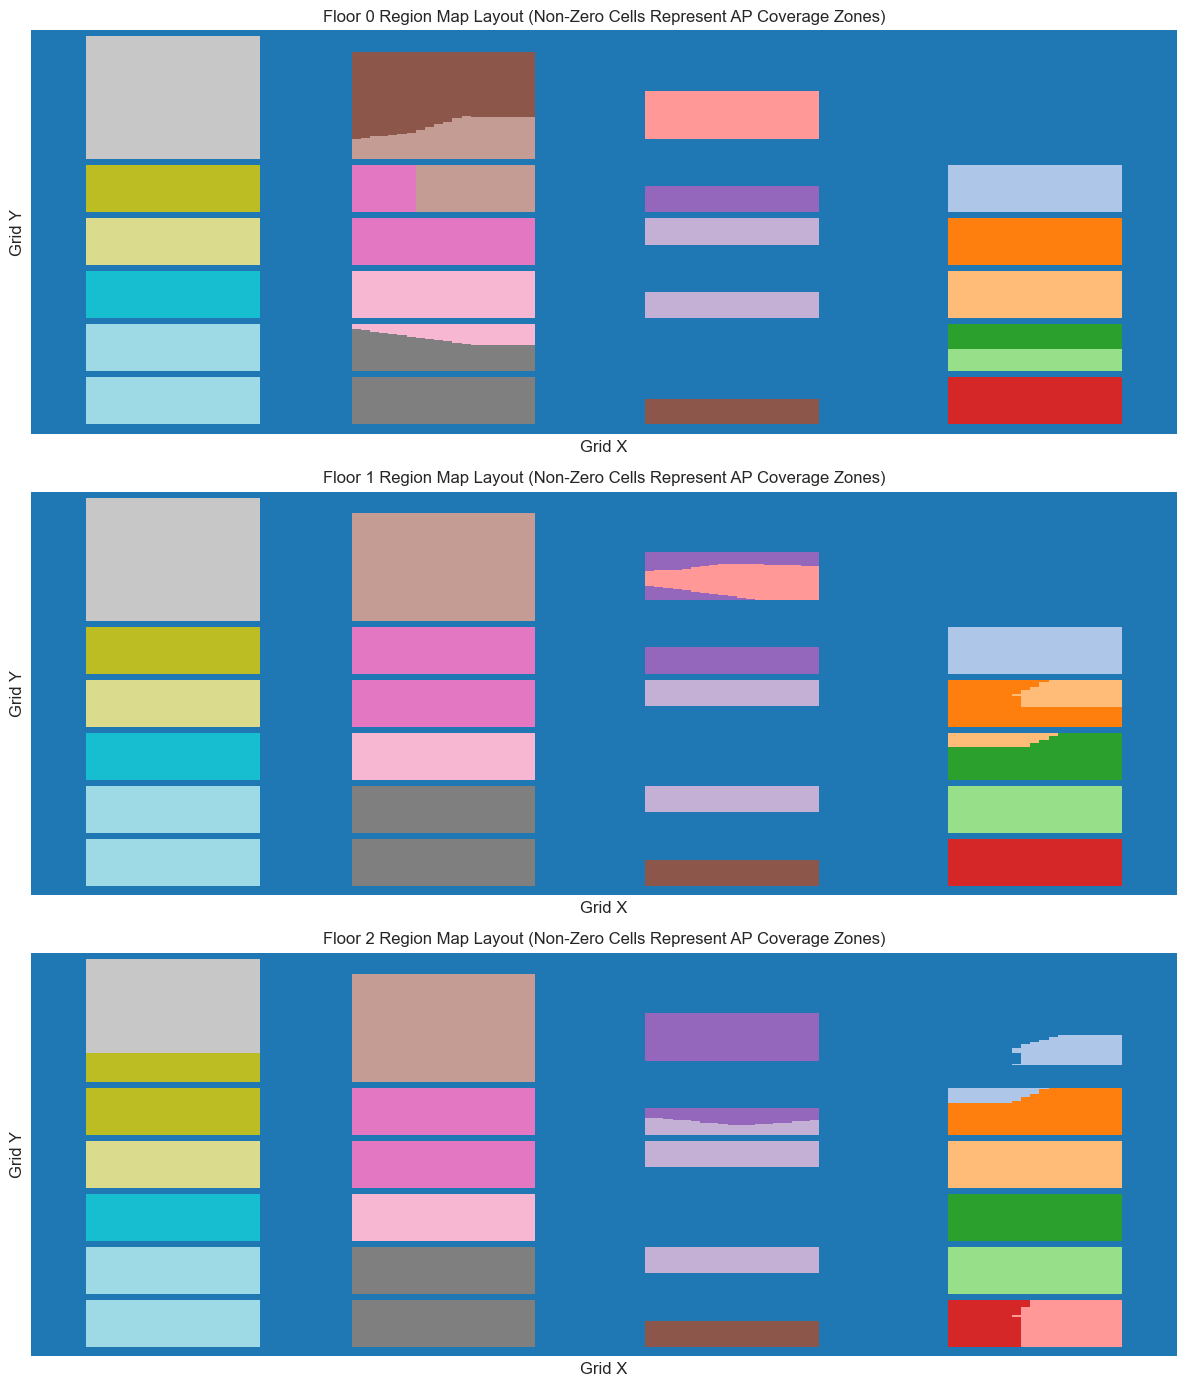

Saved: C:\Users\samar\OneDrive\Desktop\wifi congestion mangement project\predictive-bandwidth-congestion-manager\data\processed\analysis\floor_layouts.png


In [12]:
fig, axes = plt.subplots(3, 1, figsize=(12, 14))

for i, floor in enumerate([0, 1, 2]):
    if floor in maps:
        # Plot map showing AP zones
        sns.heatmap(maps[floor], ax=axes[i], cmap='tab20', cbar=False, xticklabels=False, yticklabels=False)
        axes[i].set_title(f'Floor {floor} Region Map Layout (Non-Zero Cells Represent AP Coverage Zones)')
        axes[i].set_xlabel('Grid X')
        axes[i].set_ylabel('Grid Y')

plt.tight_layout()
plot_path = os.path.join(analysis_out_dir, 'floor_layouts.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved: {plot_path}")


## 9. Dataset Findings

Based on our exploratory data analysis, here is a concise summary of the findings:

### 1. Dataset Dimensions & Volume
- **Total Files**: 62 daily CSV files (from `2023-04-18` to `2023-06-18`).
- **Total Records**: 1,267,357 observations.
- **Access Point (AP) Count**: 247 unique Access Points.
- **Observations per AP**: Exactly 5,131 observations per AP. This represents a highly balanced and complete dataset with zero dropped time records per AP.

### 2. Time Scope & Sampling Interval
- **Date Range**: April 18, 2023 00:07:30 to June 18, 2023 23:47:22 (62 days).
- **Typical Sampling Interval**: 
  - **Mean**: 17.40 minutes
  - **Median**: 16.62 minutes
  - **Minimum**: 15.83 minutes
  - **Maximum**: 35.83 minutes
  - *Observation*: The sampling interval is not exactly 15 minutes. It exhibits a minor, variable delay, averaging ~17.4 minutes between consecutive reads for a single AP. There is a maximum interval of ~35.8 minutes, indicating occasional missed polling intervals.

### 3. Connected User Statistics
- **Minimum Users**: 0 (no users connected).
- **Maximum Users**: 114 (peak users on a single AP).
- **Mean Users**: 1.35 users per observation.
- **Median Users**: 0.0 users.
- **Standard Deviation**: 3.14 users.
- **Percentage of Inactive Observations (Users = 0)**: **52.98%** of the dataset records contain 0 users. This reveals that more than half the time, APs are completely idle, typical for off-peak/night hours and low-traffic areas.

### 4. Busiest and Least-Used Access Points
- **Top 5 Busiest APs (by Mean Users)**:
  1. **AP 188**: Mean of 4.52 users (max 114 users)
  2. **AP 107**: Mean of 4.49 users (max 54 users)
  3. **AP 194**: Mean of 3.73 users (max 50 users)
  4. **AP 125**: Mean of 3.69 users (max 59 users)
  5. **AP 44**: Mean of 3.63 users (max 44 users)
- **Least-Used APs**: AP 180 has exactly 0.0 mean users (it had 0 users across all 5,131 observations). Several other APs (e.g. 117, 212, 26) average less than 0.1 users.

### 5. Data Quality Issues
- **Missing Values**: 0 missing values across all columns (`AP_id`, `Time`, `Users`).
- **Duplicates**: 0 duplicate records.
- **Invalid Timestamps**: 0 invalid timestamps. All timestamps are correctly formatted and parseable.
- **Consistency**: High quality. The number of records is identical for all APs.
- **Region Map Alignments**: The set of unique values in the region floor maps corresponds exactly to the 247 APs found in the active user logs. No missing or mismatched AP IDs were detected.

### 6. Temporal & Spatial Patterns
- **Hourly Cycle**: User counts show a highly periodic daily pattern. Peak usage occurs during core campus hours (9:00 AM to 5:00 PM), with usage decaying to near-zero between midnight and 6:00 AM.
- **Weekly Cycle**: Mid-week days (Tuesday, Wednesday, Thursday) show the highest average traffic. Mondays and Fridays show moderate activity, whereas weekends (Saturday, Sunday) show a significant drop (averaging ~1/3 of mid-week levels).
- **AP Activity Distribution**: High spatial concentration. A small fraction of APs account for the majority of the campus network load, while over 50% of observation records are zero-user states.
